# Libaries

In [442]:
# Model
import tensorflow as tf
from tensorflow.keras import Input,regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import BinaryAccuracy, Precision, Recall
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization

# Pre-Processing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
from sklearn.decomposition import PCA

# Utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve

# Configurations

## Pre-Processing

In [443]:
# Pre-Processing
DATASETS_COLUMN = 10
TRAIN_TEST_RATIO = 0.3
SELECTED_SCALER = "StandardScaler"
FEATURE_SELECTION_K = 5
PCA_K = 4

## Training

In [444]:
# Model Training
LIGHT_REGULARIZERS = regularizers.l2(0.00005)
MEDIUM_REGULARIZERS = regularizers.l2(0.0005)
HEAVY_REGULARIZERS = regularizers.l2(0.005)

In [445]:
## Class Weight
total_samples = 3000
weight_constant_class_0 = total_samples * 1.0
weight_constant_class_1 = total_samples * 1.1

In [446]:
# Early stopping threshold
EARLY_STOPPING_THRESHOLD = 0.86

In [447]:
# Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=10,
    min_lr=0.00001
)

In [448]:
# Configs
model_configs = {
    "epochs": 100,
    "batch_size": 32,
    "validation_split": 0.2
    }

## Model

In [449]:

model_architectures = [
    Dense(48, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(24, activation='relu', kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(12, activation='relu'),
    BatchNormalization(),
    Dropout(0.0),

    Dense(1, activation='sigmoid')
]

# Load Data

In [450]:
def load_data_from_csv(address: str):
    try:
        data = pd.read_csv(address)
        print(f"CSV Data shape: {data.shape}\n")
        return data

    except Exception as e:
        raise Exception(f"Error loading CSV file on {address} : {e}")

In [451]:
data = load_data_from_csv("Churn_Modelling.csv")
data.head()

CSV Data shape: (10000, 14)



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Pre-Processing

In [452]:
# Removing unnecessary columns
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print(f"CSV Data shape (after drop): {data.shape}\n")
data.head()

CSV Data shape (after drop): (10000, 11)



,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Splitting into Features and Target

In [453]:
def get_features_and_target(data: pd.DataFrame, target_column: int):
    features = data.iloc[:, :target_column]
    target = data.iloc[:, target_column]

    print(f"Features shape: {features.shape}")
    print(f"Target shape: {target.shape}")

    return features, target

In [454]:
x,y = get_features_and_target(data, -1)

Features shape: (10000, 10)
Target shape: (10000,)


## Label Encodding

In [455]:
# Labeling Every Categorical Data
def encode_data(data: pd.DataFrame, keys: list):
    encoders = {}

    for key in keys:
        encoder = LabelEncoder()
        data[key] = encoder.fit_transform(data[key])
        encoders[key] = encoder

    return data, encoders

In [456]:
x,encoders = encode_data(x,["Gender","Geography"])

x.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


## Split Data $\rightarrow$ Train Set, Test Set

In [457]:
def split_datasets_to_train_test(x,y,ratio):
    x_train, x_test, y_train, y_test = train_test_split(x, y,stratify=y,test_size=0.3)
    return x_train, x_test, y_train, y_test

In [458]:
x_train, x_test, y_train, y_test = split_datasets_to_train_test(x,y,TRAIN_TEST_RATIO)

print(f"Features train set shape: {x_train.shape}")
print(f"Targets train set shape: {y_train.shape}")
print(f"Features test set shape: {x_test.shape}")
print(f"Targets train set shape: {y_test.shape}")

Features train set shape: (7000, 10)
Targets train set shape: (7000,)
Features test set shape: (3000, 10)
Targets train set shape: (3000,)


## Scale Data

In [459]:
def _standard_scaler(train_set: pd.DataFrame,test_set: pd.DataFrame):
    scaler = StandardScaler()
    train_set = scaler.fit_transform(train_set)
    test_set = scaler.transform(test_set)
    return train_set, test_set

def _min_max_scaler(train_set: pd.DataFrame,test_set: pd.DataFrame):
    scaler = MinMaxScaler()
    train_set = scaler.fit_transform(train_set)
    test_set = scaler.transform(test_set)
    return train_set, test_set

def normalize_data(train_set: pd.DataFrame,test_set: pd.DataFrame, scaler: str):
    match (scaler):
        case "StandardScaler":
            return _standard_scaler(train_set,test_set)
        case "MinMaxScaler":
            return _min_max_scaler(train_set,test_set)

In [460]:
x_train, x_test = normalize_data(x_train,x_test,SELECTED_SCALER)

print(f"Preview of features training set:\n {x_train}")
print(f"Preview of features testing set:\n {x_test}")

Preview of features training set:
 [[-2.2762676  -0.90303156  0.9147613  ...  0.64820241  0.97600215
   1.18263174]
 [-1.14875137 -0.90303156  0.9147613  ...  0.64820241 -1.02458791
   0.36731287]
 [ 2.05794617  1.51056941 -1.09318135 ...  0.64820241 -1.02458791
  -0.50031869]
 ...
 [-0.6936072   0.30376892  0.9147613  ...  0.64820241 -1.02458791
  -0.12252324]
 [ 0.72354623  1.51056941  0.9147613  ... -1.54272799 -1.02458791
  -0.94471947]
 [ 0.83733227  0.30376892 -1.09318135 ...  0.64820241 -1.02458791
   0.3630407 ]]
Preview of features testing set:
 [[-0.96255603 -0.90303156  0.9147613  ...  0.64820241 -1.02458791
   1.44791255]
 [ 1.50970433 -0.90303156  0.9147613  ... -1.54272799 -1.02458791
   0.43703316]
 [-0.19708629 -0.90303156 -1.09318135 ...  0.64820241  0.97600215
  -0.64763603]
 ...
 [ 0.00979742  1.51056941  0.9147613  ... -1.54272799  0.97600215
   1.21769307]
 [ 0.6718253  -0.90303156 -1.09318135 ...  0.64820241 -1.02458791
  -1.48356594]
 [ 1.0338718  -0.90303156  0.

## Feature Selection

### Correlation Based Feature Selection

In [461]:
def get_correlation(x,y):
    corr = np.corrcoef(x,y,rowvar=False)
    print("Correlation of Features and Target")
    display(pd.DataFrame(corr))

In [462]:
get_correlation(x_train,y_train)

Correlation of Features and Target


,0,1,2,3,4,5,6,7,8,9,10
0,1.000000,0.002051,0.000749,0.000265,-0.014977,0.012081,0.008546,0.008342,0.039773,0.015345,-0.022023
1,0.002051,1.000000,0.007368,0.017442,0.010055,0.075257,0.004406,-0.004268,0.009104,-0.000932,0.035076
2,0.000749,0.007368,1.000000,-0.037599,0.015546,0.017426,-0.026783,-0.006592,0.016770,-0.012255,-0.106372
3,0.000265,0.017442,-0.037599,1.000000,0.003346,0.032268,-0.036008,-0.017921,0.083317,-0.007618,0.283233
4,-0.014977,0.010055,0.015546,0.003346,1.000000,-0.006310,0.018316,0.034981,-0.029399,0.013942,-0.000497
5,0.012081,0.075257,0.017426,0.032268,-0.006310,1.000000,-0.313490,-0.010564,-0.017775,0.013842,0.120375
6,0.008546,0.004406,-0.026783,-0.036008,0.018316,-0.313490,1.000000,0.011386,0.018066,0.012734,-0.043999
7,0.008342,-0.004268,-0.006592,-0.017921,0.034981,-0.010564,0.011386,1.000000,-0.017127,-0.010742,-0.014072
8,0.039773,0.009104,0.016770,0.083317,-0.029399,-0.017775,0.018066,-0.017127,1.000000,-0.015389,-0.150660
9,0.015345,-0.000932,-0.012255,-0.007618,0.013942,0.013842,0.012734,-0.010742,-0.015389,1.000000,0.024888


Since the data are mostly uncorrelated, means correlation based feature selection are not useful.

### F-Regression Selection

In [463]:
def feature_selection(x_train,y_train,x_test,k):
    selector = SelectKBest(score_func=f_regression, k=k)
    x_train_new = selector.fit_transform(x_train, y_train)
    x_test_new = selector.transform(x_test)
    selected_columns = selector.get_support(indices=True)
    return x_train_new, x_test_new, selected_columns

In [464]:
# x_train, x_test, selected_columns = feature_selection(x_train,y_train,x_test,FEATURE_SELECTION_K)

# print(f"New features training set shape: {x_train.shape}")
# print(f"New features testing set shape: {x_test.shape}")
# print("Selected features:", [(data.columns[selected_columns])])

## Dimensionality Reduction

In [465]:
def dimensionality_reduction(train,test,k):
    pca = PCA(n_components=k)
    train_pca = pca.fit_transform(train)
    test_pca = pca.transform(test)
    explained_variance = pca.explained_variance_ratio_
    return train_pca, test_pca, explained_variance

In [466]:
# x_train, x_test, explained_variance = dimensionality_reduction(x_train,x_test,PCA_K)

# print(f"New features training set shape: {x_train.shape}")
# print(f"New features testing set shape: {x_test.shape}")
# print(f"Explained variance: {explained_variance}")
# print(f"Percentage of explained variance: {sum(explained_variance)*100}%")

# Training Model

## Create Model

In [467]:
def create_model(input_columns,model_architectures):
    model = Sequential()
    model.add(Input(shape=(input_columns,)))
    for layer_config in model_architectures:
            model.add(layer_config)
    return model

In [468]:
model = create_model(x_train.shape[1],model_architectures)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 48)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,353 (9.19 KB)

 Trainable params: 2,185 (8.54 KB)

 Non-trainable params: 168 (672.00 B)

## Model Compile

In [469]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss


In [470]:
model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])

## Model Fit

In [471]:
class EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, target_val_acc=0.80):
        super().__init__()
        self.target_val_acc = target_val_acc

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get("val_accuracy")
        train_acc = logs.get("accuracy")

        if val_acc is not None and val_acc >= self.target_val_acc:
            print(f"\n--- EARLY STOPPING TRIGGERED ---")
            print(f"Epoch {epoch + 1} Training Accuracy: {train_acc:.4f}")
            print(f"Epoch {epoch + 1} Validation Accuracy: {val_acc:.4f}")
            print(f"Validation accuracy reached target of {self.target_val_acc}. Stopping.")
            self.model.stop_training = True

In [472]:
# Add "Punishment"
wa = (1 / 2377) * weight_constant_class_0
wb = (1 / 623) * weight_constant_class_1
class_weight = {0: wa, 1: wb}

print(f"Weight for class 0: {wa:.2f}")
print(f"Weight for class 1: {wb:.2f}")

Weight for class 0: 1.26
Weight for class 1: 5.30


### Epoch Training Sequence

In [473]:
early_stopping = EarlyStopping(target_val_acc=EARLY_STOPPING_THRESHOLD)

history = model.fit(
    x_train,
    y_train,
    epochs=model_configs['epochs'],
    batch_size=model_configs['batch_size'],
    validation_split=model_configs["validation_split"],
    callbacks=[reduce_lr,early_stopping],
    class_weight=class_weight
)

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6427 - loss: 0.0932 - val_accuracy: 0.7793 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7686 - loss: 0.0601 - val_accuracy: 0.8071 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7916 - loss: 0.0545 - val_accuracy: 0.8229 - val_loss: 0.0155 - learning_rate: 0.0010
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8086 - loss: 0.0506 - val_accuracy: 0.8221 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8087 - loss: 0.0485 - val_accuracy: 0.8307 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8155 - loss: 0.0470 - val_accuracy: 0.8336 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8227 - loss: 0.

In [474]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 48)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 24)             │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 12)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 12)             │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,725 (26.27 KB)

 Trainable params: 2,185 (8.54 KB)

 Non-trainable params: 168 (672.00 B)

 Optimizer params: 4,372 (17.08 KB)

## Plotting Training Curve

In [475]:
def plot_history(history):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history['accuracy'])
    plt.plot(history['val_accuracy'])
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(['Train','Validation'],loc="upper left")
    plt.title("Model Accuracy")

    plt.subplot(1,2,2)
    plt.plot(history['loss'])
    plt.plot(history['val_loss'])
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(['Train','Validation'],loc="upper left")
    plt.title("Model Loss")

    plt.show()


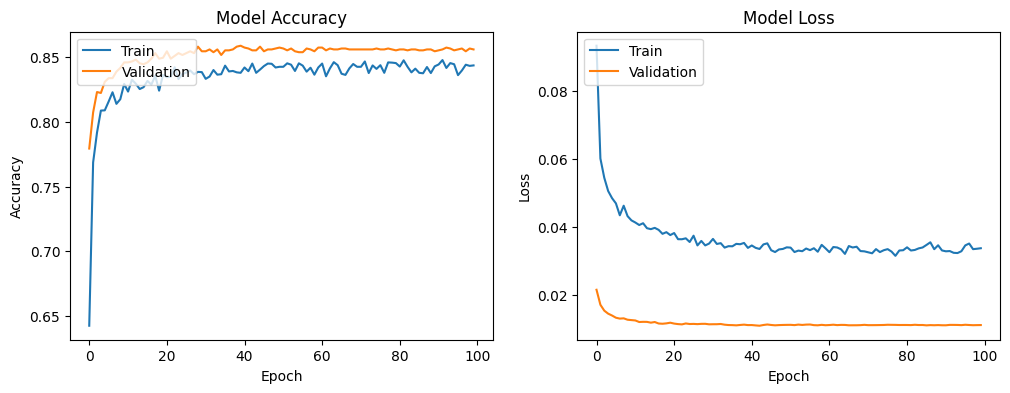

In [476]:
plot_history(history.history)

# Evaluate Model

In [477]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8497 - loss: 0.0110
Test Loss: 0.010987013578414917
Test Accuracy: 0.8496666550636292


In [478]:
targets_probability = model.predict(x_test)
targets_prediction = targets_probability > 0.50

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


### Results (Default threshold $p \geq 0.5$)

              precision    recall  f1-score   support

           0       0.89      0.92      0.91      2389
           1       0.65      0.56      0.60       611

    accuracy                           0.85      3000
   macro avg       0.77      0.74      0.76      3000
weighted avg       0.84      0.85      0.85      3000



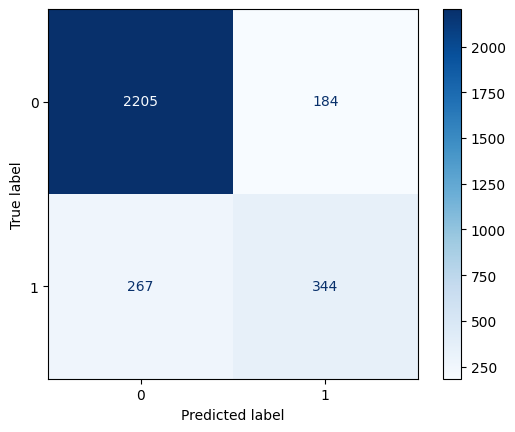

In [479]:
cm = confusion_matrix(y_test, targets_prediction)
cm_display = ConfusionMatrixDisplay(cm)
cm_display.plot(cmap="Blues")
print(classification_report(y_test, targets_prediction))

## Using Optimal Threshold

In [480]:
y_pred_proba = model.predict(x_train)

precisions, recalls, thresholds = precision_recall_curve(y_train, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
optimal_threshold = thresholds[np.argmax(f1_scores)]

print(f"Optimal threshold: {optimal_threshold:.4f}")

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Optimal threshold: 0.4345


In [481]:
y_pred_proba_test = model.predict(x_test)
y_pred_optimal = (y_pred_proba_test >= optimal_threshold).astype(int)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


### Results (Optimal Threshold)

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      2389
           1       0.59      0.62      0.60       611

    accuracy                           0.83      3000
   macro avg       0.74      0.75      0.75      3000
weighted avg       0.84      0.83      0.84      3000



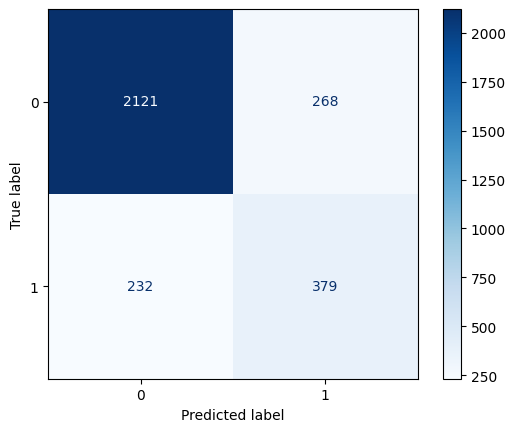

In [482]:
cm = confusion_matrix(y_test, y_pred_optimal)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
print(classification_report(y_test, y_pred_optimal))